# S6E5 - Predicting F1 Pit Stops (V1)

This notebook is designed for a 1-hour workflow:
1. ETL and data quality checks
2. Focused EDA for race strategy intuition
3. Baseline model (Logistic Regression)
4. Improved model (LightGBM)
5. Kaggle-ready V1 submission

## 1) Setup

In [1]:
import os
import glob
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

import lightgbm as lgb

warnings.filterwarnings("ignore")
np.random.seed(42)
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)

print("Libraries loaded.")

Libraries loaded.


## 2) ETL: Load Data and Sanity Checks

In [2]:
def find_input_dir():
    if os.path.exists("/kaggle/input"):
        candidates = glob.glob("/kaggle/input/*")
        for path in candidates:
            if all(os.path.exists(os.path.join(path, f)) for f in ["train.csv", "test.csv", "sample_submission.csv"]):
                return path
        return candidates[0] if candidates else "/kaggle/input"
    return "./data"

input_dir = find_input_dir()
output_dir = "/kaggle/working" if os.path.exists("/kaggle/working") else "./submissions"
os.makedirs(output_dir, exist_ok=True)

train_df = pd.read_csv(os.path.join(input_dir, "train.csv"))
test_df = pd.read_csv(os.path.join(input_dir, "test.csv"))
sample_sub = pd.read_csv(os.path.join(input_dir, "sample_submission.csv"))

TARGET = "PitNextLap"

print(f"Input dir: {input_dir}")
print(f"Output dir: {output_dir}")
print(f"Train shape: {train_df.shape}")
print(f"Test shape: {test_df.shape}")
display(train_df.head(3))

Input dir: ./data
Output dir: ./submissions
Train shape: (439140, 16)
Test shape: (188165, 15)


,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
0,0,D109,HARD,Canadian Grand Prix,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0,1.0
1,1,D086,HARD,Dutch Grand Prix,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0,0.0
2,2,ZON,HARD,Austrian Grand Prix,2022,0,59,3,22.0,13,70.945,-7.540,-100.529,0.819444,3.0,1.0


In [3]:
missing_train = train_df.isna().sum().sum()
missing_test = test_df.isna().sum().sum()

print("Missing values (train):", int(missing_train))
print("Missing values (test):", int(missing_test))
print("Duplicate ids in train:", int(train_df["id"].duplicated().sum()))
print("Duplicate ids in test:", int(test_df["id"].duplicated().sum()))
print("Target distribution:")
print(train_df[TARGET].value_counts(normalize=True).rename("ratio"))

Missing values (train): 0
Missing values (test): 0
Duplicate ids in train: 0
Duplicate ids in test: 0
Target distribution:
PitNextLap
0.0    0.801018
1.0    0.198982
Name: ratio, dtype: float64


## 3) EDA (Focused and Interview-Friendly)

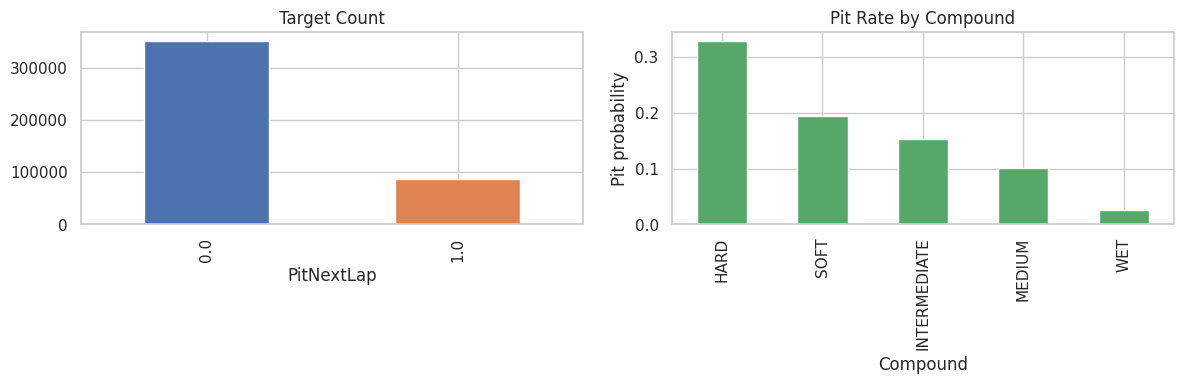

Quick read: class imbalance exists, and compound clearly affects pit behavior.


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

train_df[TARGET].value_counts().sort_index().plot(
    kind="bar",
    ax=axes[0],
    color=["#4C72B0", "#DD8452"]
)
axes[0].set_title("Target Count")
axes[0].set_xlabel("PitNextLap")

pit_rate_by_compound = train_df.groupby("Compound")[TARGET].mean().sort_values(ascending=False)
pit_rate_by_compound.plot(kind="bar", ax=axes[1], color="#55A868")
axes[1].set_title("Pit Rate by Compound")
axes[1].set_ylabel("Pit probability")

plt.tight_layout()
plt.show()

print("Quick read: class imbalance exists, and compound clearly affects pit behavior.")

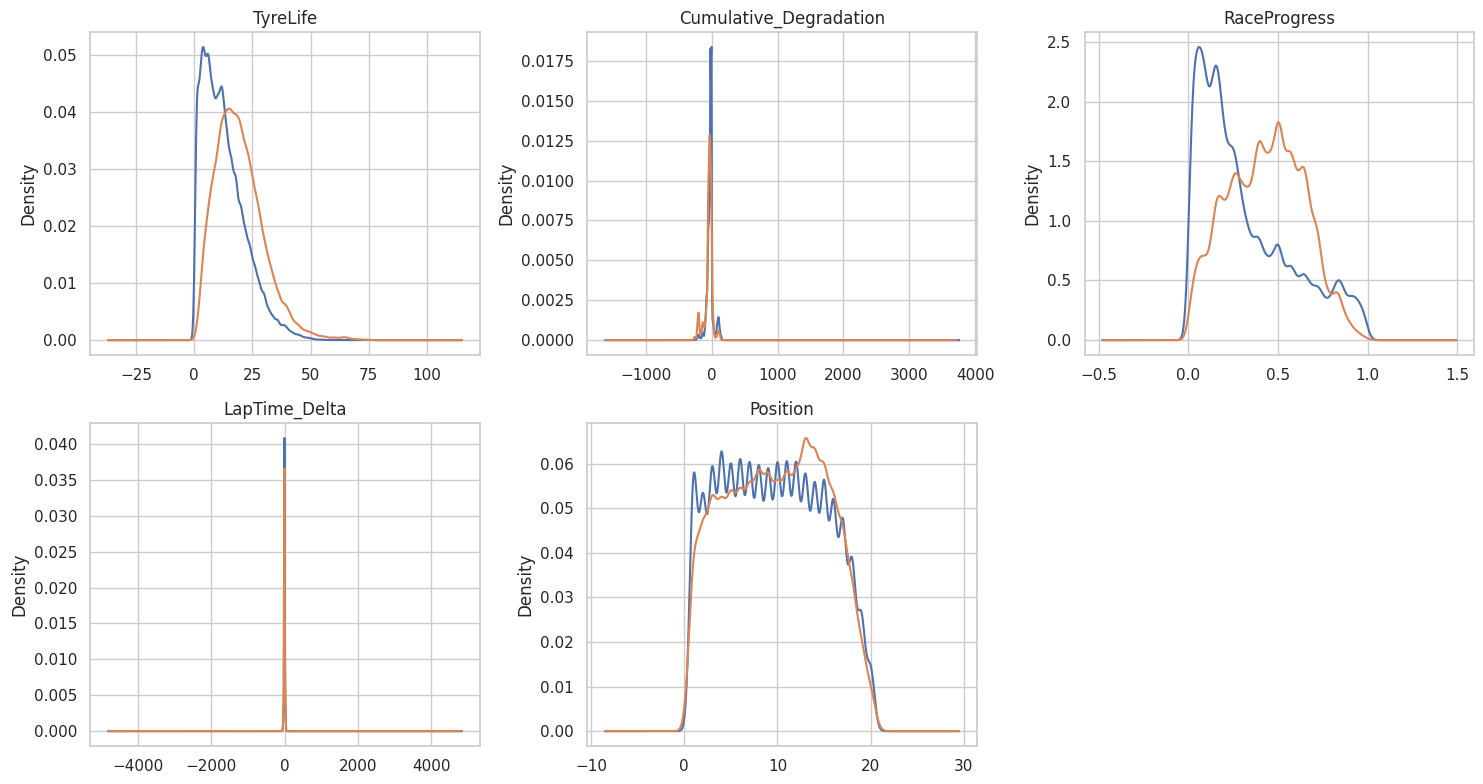

In [5]:
numeric_cols = [
    "TyreLife",
    "Cumulative_Degradation",
    "RaceProgress",
    "LapTime_Delta",
    "Position"
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for idx, col in enumerate(numeric_cols):
    ax = axes[idx]
    for label, color, name in [(0, "#4C72B0", "No Pit"), (1, "#DD8452", "Pit")]:
        train_df.loc[train_df[TARGET] == label, col].plot(
            kind="kde",
            ax=ax,
            label=name,
            color=color
        )
    ax.set_title(col)

for j in range(len(numeric_cols), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

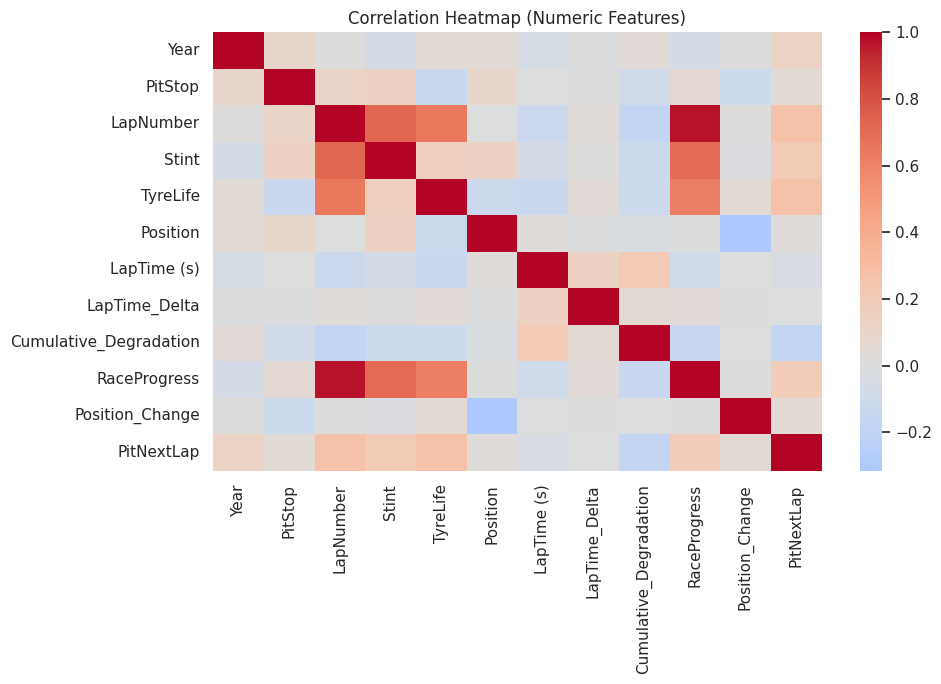

In [6]:
corr_cols = [
    "Year", "PitStop", "LapNumber", "Stint", "TyreLife",
    "Position", "LapTime (s)", "LapTime_Delta",
    "Cumulative_Degradation", "RaceProgress", "Position_Change", TARGET
]

corr = train_df[corr_cols].corr(numeric_only=True)
plt.figure(figsize=(10, 7))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap (Numeric Features)")
plt.tight_layout()
plt.show()

## 4) Feature Engineering and Model Matrix

In [9]:
def engineer_features(df):
    df = df.copy()

    expected_stint = {"SOFT": 22.0, "MEDIUM": 32.0, "HARD": 45.0, "INTERMEDIATE": 20.0, "WET": 20.0}
    df["TyreLifeExpected"] = df["Compound"].map(expected_stint).fillna(30.0)
    df["TyreLifePct"] = df["TyreLife"] / (df["TyreLifeExpected"] + 1e-6)
    df["TyreOverExpected"] = (df["TyreLifePct"] > 1.0).astype(int)

    df["DegPerLap"] = df["Cumulative_Degradation"] / (df["TyreLife"] + 1.0)
    df["IsLapTimeSlower"] = (df["LapTime_Delta"] > 0).astype(int)
    df["TyreAge_x_Deg"] = df["TyreLife"] * np.abs(df["Cumulative_Degradation"])
    df["Progress_x_TyreLife"] = df["RaceProgress"] * df["TyreLife"]

    df["RacePhase"] = pd.cut(
        df["RaceProgress"],
        bins=[-0.001, 0.33, 0.66, 1.0],
        labels=["early", "mid", "late"]
    ).astype(str)

    df["PositionBand"] = pd.cut(
        df["Position"],
        bins=[0, 3, 10, 20, 100],
        labels=["front", "midfield", "back", "tail"]
    ).astype(str)

    return df

train_fe = engineer_features(train_df)
test_fe = engineer_features(test_df)

target_col = TARGET
id_col = "id"
feature_cols = [c for c in train_fe.columns if c not in [target_col, id_col]]

cat_cols = train_fe[feature_cols].select_dtypes(include=["object", "string", "category"]).columns.tolist()

for c in cat_cols:
    le = LabelEncoder()
    all_values = pd.concat([train_fe[c], test_fe[c]], axis=0).astype(str)
    le.fit(all_values)
    train_fe[c] = le.transform(train_fe[c].astype(str))
    test_fe[c] = le.transform(test_fe[c].astype(str))

X = train_fe[feature_cols].copy()
y = train_fe[target_col].astype(int).copy()
X_test = test_fe[feature_cols].copy()

# Final safety net: if any non-numeric column remains, encode it.
remaining_non_numeric = X.select_dtypes(include=["object", "string", "category"]).columns.tolist()
for c in remaining_non_numeric:
    le = LabelEncoder()
    all_values = pd.concat([X[c], X_test[c]], axis=0).astype(str)
    le.fit(all_values)
    X[c] = le.transform(X[c].astype(str))
    X_test[c] = le.transform(X_test[c].astype(str))

X = X.apply(pd.to_numeric, errors="coerce")
X_test = X_test.apply(pd.to_numeric, errors="coerce")

if X.isna().any().any() or X_test.isna().any().any():
    fill_values = X.median(numeric_only=True)
    X = X.fillna(fill_values)
    X_test = X_test.fillna(fill_values)

print(f"Feature count: {len(feature_cols)}")
print(f"Categorical encoded: {len(cat_cols)}")
print(f"X shape: {X.shape}, X_test shape: {X_test.shape}")
print(f"Remaining non-numeric in X: {X.select_dtypes(include=['object', 'string', 'category']).shape[1]}")

Feature count: 23
Categorical encoded: 5
X shape: (439140, 23), X_test shape: (188165, 23)
Remaining non-numeric in X: 0


## 5) Baseline Model: Logistic Regression

In [10]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_test_scaled = scaler.transform(X_test)

lr = LogisticRegression(class_weight="balanced", max_iter=500, random_state=42)
lr_scores = cross_val_score(lr, X_scaled, y, cv=cv, scoring="roc_auc", n_jobs=-1)

print("Logistic Regression ROC-AUC (5-fold):")
print("folds:", np.round(lr_scores, 5))
print("mean :", round(lr_scores.mean(), 5))
print("std  :", round(lr_scores.std(), 5))

lr.fit(X_scaled, y)
pred_lr_test = lr.predict_proba(X_test_scaled)[:, 1]

sub_lr = sample_sub.copy()
sub_lr[target_col] = pred_lr_test
sub_lr_path = os.path.join(output_dir, "submission_v1_baseline_logreg.csv")
sub_lr.to_csv(sub_lr_path, index=False)
print(f"Saved baseline submission: {sub_lr_path}")

/home/shiftmint/.pyenv/versions/3.14.3/lib/python3.14/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/home/shiftmint/.pyenv/versions/3.14.3/lib/python3.14/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/home/shiftmint/.pyenv/versions/3.14.3/lib/python3.14/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refr

Logistic Regression ROC-AUC (5-fold):
folds: [0.83841 0.83601 0.83633 0.83433 0.83689]
mean : 0.83639
std  : 0.00132
Saved baseline submission: ./submissions/submission_v1_baseline_logreg.csv


## 6) Improved Model: LightGBM with Stratified CV

In [11]:
neg_count = (y == 0).sum()
pos_count = (y == 1).sum()
scale_pos_weight = neg_count / max(pos_count, 1)

lgb_params = {
    "n_estimators": 700,
    "learning_rate": 0.05,
    "num_leaves": 96,
    "max_depth": -1,
    "min_child_samples": 60,
    "subsample": 0.85,
    "colsample_bytree": 0.85,
    "reg_alpha": 0.05,
    "reg_lambda": 0.8,
    "scale_pos_weight": scale_pos_weight,
    "objective": "binary",
    "metric": "auc",
    "random_state": 42,
    "n_jobs": -1,
    "verbosity": -1
}

oof_lgb = np.zeros(len(X))
test_lgb = np.zeros(len(X_test))
fold_auc = []
fi_frames = []

for fold, (tr_idx, va_idx) in enumerate(cv.split(X, y), start=1):
    X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
    y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]

    model = lgb.LGBMClassifier(**lgb_params)
    model.fit(
        X_tr,
        y_tr,
        eval_set=[(X_va, y_va)],
        callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
    )

    pred_va = model.predict_proba(X_va)[:, 1]
    pred_te = model.predict_proba(X_test)[:, 1]

    oof_lgb[va_idx] = pred_va
    test_lgb += pred_te / cv.n_splits

    auc = roc_auc_score(y_va, pred_va)
    fold_auc.append(auc)
    print(f"Fold {fold}: AUC={auc:.5f}, best_iter={model.best_iteration_}")

    fi_frames.append(pd.DataFrame({"feature": X.columns, "importance": model.feature_importances_}))

oof_auc = roc_auc_score(y, oof_lgb)
print()
print(f"LightGBM OOF AUC: {oof_auc:.5f}")
print(f"Mean fold AUC   : {np.mean(fold_auc):.5f} +/- {np.std(fold_auc):.5f}")
print(f"Baseline mean   : {lr_scores.mean():.5f}")
print(f"Improvement     : {oof_auc - lr_scores.mean():.5f}")

Fold 1: AUC=0.94930, best_iter=699
Fold 2: AUC=0.94773, best_iter=689
Fold 3: AUC=0.94842, best_iter=675
Fold 4: AUC=0.94752, best_iter=700
Fold 5: AUC=0.94865, best_iter=554

LightGBM OOF AUC: 0.94832
Mean fold AUC   : 0.94832 +/- 0.00064
Baseline mean   : 0.83639
Improvement     : 0.11193


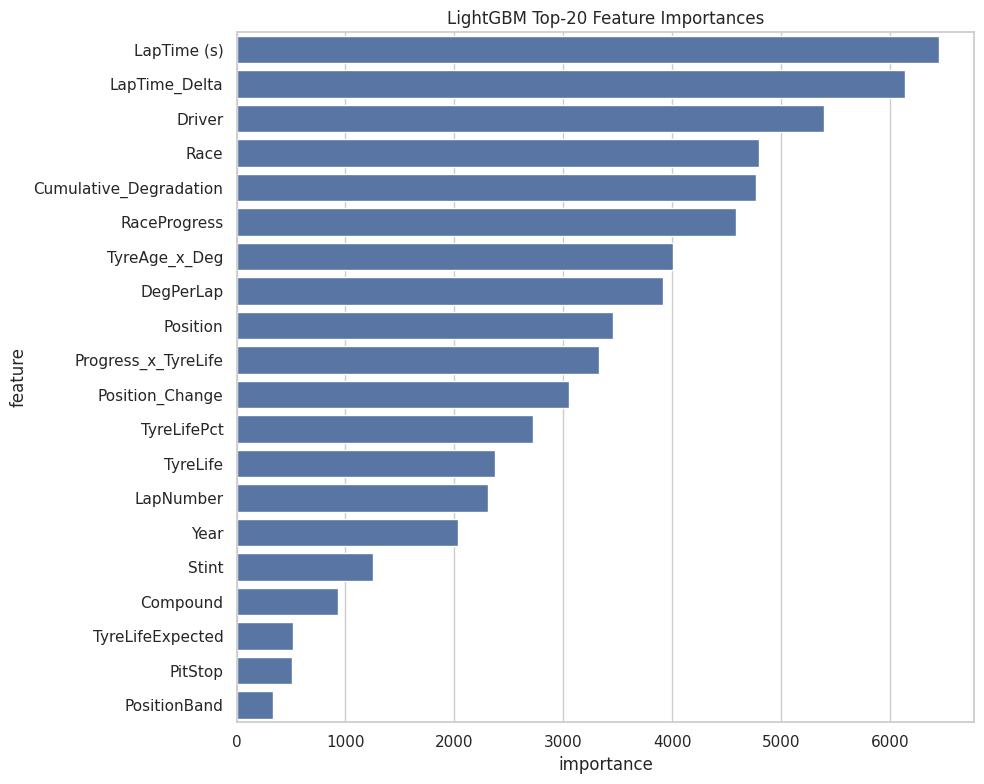

,feature,importance
6,LapTime (s),6450.8
7,LapTime_Delta,6137.2
3,Driver,5394.4
13,Race,4794.4
1,Cumulative_Degradation,4769.6
15,RaceProgress,4586.4
17,TyreAge_x_Deg,4004.6
2,DegPerLap,3918.8
9,Position,3456.0
12,Progress_x_TyreLife,3331.8


In [12]:
fi = pd.concat(fi_frames, axis=0).groupby("feature", as_index=False)["importance"].mean()
fi = fi.sort_values("importance", ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(data=fi.head(20), x="importance", y="feature", color="#4C72B0")
plt.title("LightGBM Top-20 Feature Importances")
plt.tight_layout()
plt.show()

display(fi.head(10))

## 7) Final V1 Submission

In [13]:
sub_lgb = sample_sub.copy()
sub_lgb[target_col] = test_lgb
sub_lgb_path = os.path.join(output_dir, "submission_v1_lgbm.csv")
sub_lgb.to_csv(sub_lgb_path, index=False)

final_path = os.path.join(output_dir, "submission.csv")
sub_lgb.to_csv(final_path, index=False)

print("Saved improved submission:", sub_lgb_path)
print("Saved Kaggle default submission:", final_path)
print("Test prediction summary:")
print(sub_lgb[target_col].describe())
display(sub_lgb.head(10))

Saved improved submission: ./submissions/submission_v1_lgbm.csv
Saved Kaggle default submission: ./submissions/submission.csv
Test prediction summary:
count    188165.000000
mean          0.289075
std           0.358357
min           0.000274
25%           0.009485
50%           0.067052
75%           0.632592
max           0.995329
Name: PitNextLap, dtype: float64


,id,PitNextLap
0,439140,0.019465
1,439141,0.010315
2,439142,0.007360
3,439143,0.413134
4,439144,0.960302
5,439145,0.349747
6,439146,0.001722
7,439147,0.026533
8,439148,0.097051
9,439149,0.003953


## 8) Successfully Run Notes

- Why baseline first: gives a reliable floor and validates the pipeline.
- Why LightGBM improved: captures non-linear race dynamics and feature interactions.
- Why AUC: robust for class imbalance and aligned with competition metric.
- What to try in V2: target encoding for Driver/Race, time-window features, and Optuna tuning.